In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster



In [3]:
df=pd.read_csv('Global_development_cleaned.csv')
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,44.1,87931.0,Algeria,39.999418,26998.000000,54790058957,0.035,60,302.068503,...,71.0,67.0,0.0,0.342,0.619,0.039,31719449,0.599,102000000,363.977744
1,0.050,44.1,9542.0,Angola,39.999418,7499.000000,9129594819,0.034,22,302.068503,...,47.0,44.0,0.0,0.476,0.499,0.025,13924930,0.324,34000000,353.406807
2,0.043,44.1,1617.0,Benin,39.999418,1983.000000,2359122303,0.043,15,302.068503,...,57.0,53.0,0.0,0.454,0.517,0.029,6949366,0.383,77000000,314.265447
3,0.027,44.1,4276.0,Botswana,39.999418,1836.000000,5788311645,0.047,152,302.068503,...,52.0,49.0,0.1,0.383,0.587,0.029,1755375,0.532,227000000,367.023018
4,0.046,44.1,1041.0,Burkina Faso,39.999418,77236.840896,2610959139,0.051,12,302.068503,...,52.0,49.0,0.0,0.468,0.505,0.028,11607944,0.178,23000000,296.415033


In [4]:

country_names = df['Country']


df = df.drop('Country', axis=1)

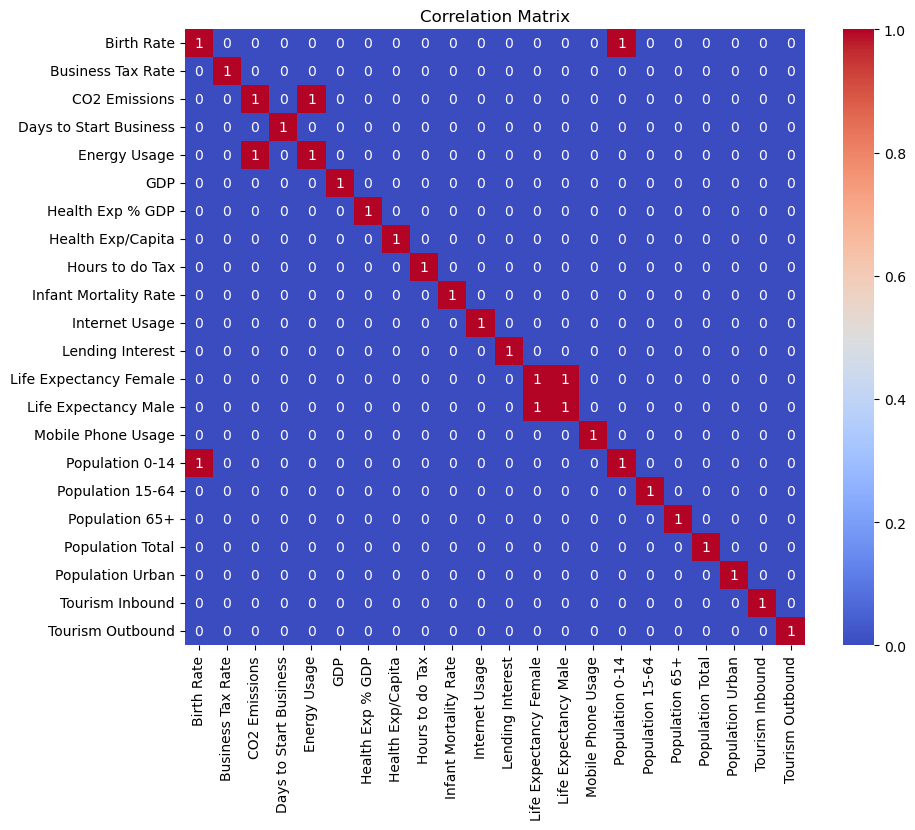

Dropped columns: ['Energy Usage', 'Life Expectancy Male', 'Population 0-14']


In [5]:
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix>0.9,annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df = df.drop(columns=to_drop)
print("Dropped columns:", to_drop)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original:", X_scaled.shape)
print("Reduced:", X_pca.shape)

Original: (2704, 19)
Reduced: (2704, 13)


# HIERARCHICAL CLUSTERING

In [8]:
linked = linkage(X_pca, method='ward')

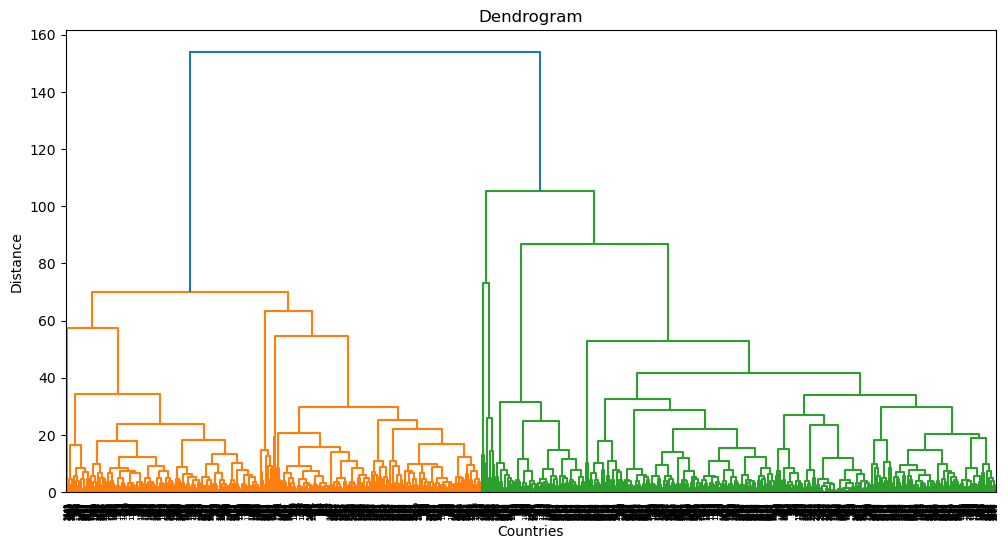

In [9]:
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [10]:
hc_labels = fcluster(linked, t=3, criterion='maxclust')

df['HC_Cluster'] = hc_labels

In [11]:
hc_score = silhouette_score(X_pca, hc_labels)
print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.27282874581567995


# K-Means Clustering

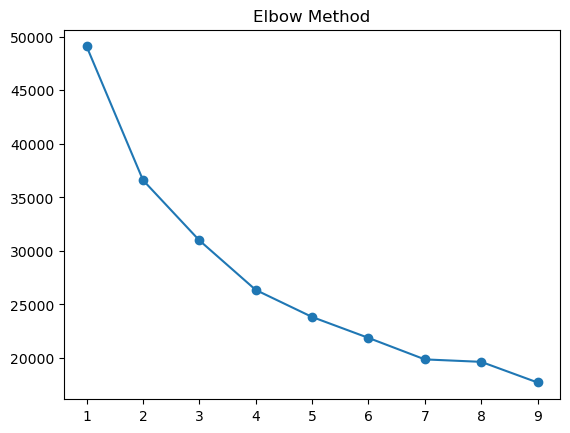

In [12]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.show()

#### apply k-mean cluster

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

df['KMeans_Cluster'] = kmeans_labels

In [14]:
k_score = silhouette_score(X_pca, kmeans_labels)
print("K-Means Score:", k_score)

K-Means Score: 0.29232244813854713


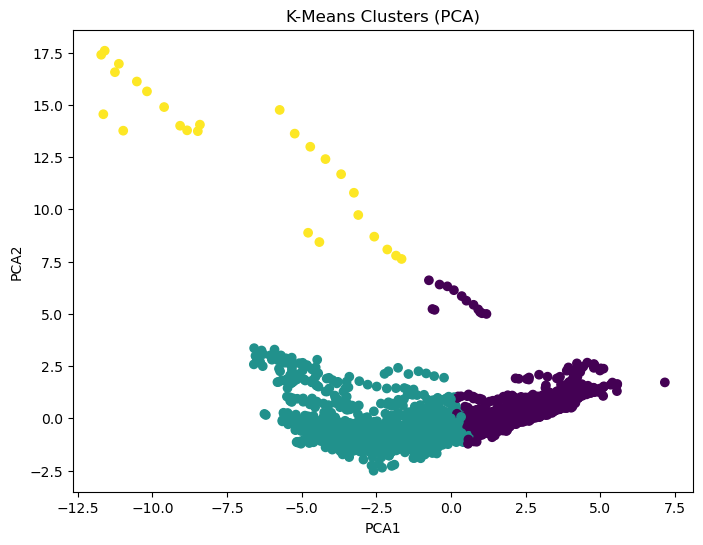

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['KMeans_Cluster'])
plt.title("K-Means Clusters (PCA)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()


# DBSCAN (Tuned)

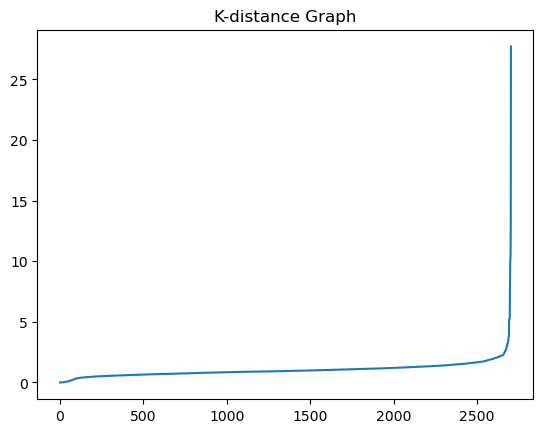

In [16]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])
plt.plot(distances)
plt.title("K-distance Graph")
plt.show()

In [17]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

In [18]:
if len(set(db_labels)) > 1:
    db_score = silhouette_score(X_scaled, db_labels)
    print("DBSCAN Score:", db_score)
else:
    print("DBSCAN not suitable")

DBSCAN Score: -0.11532465976179974


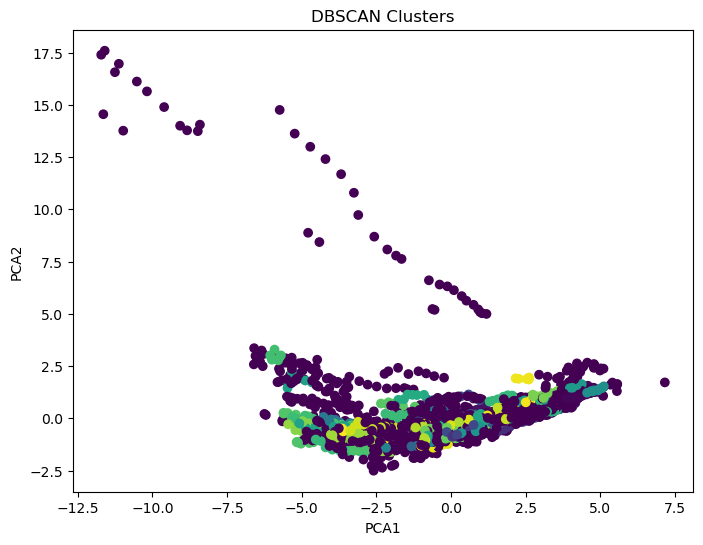

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['DBSCAN_Cluster'])
plt.title("DBSCAN Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [20]:
cluster_names = {
    0: "Developed",
    1: "Developing",
    2: "Underdeveloped"
}

df['Cluster_Name'] = df['KMeans_Cluster'].map(cluster_names)
df['Country'] = country_names

df[['Country', 'Cluster_Name']].head()

,Country,Cluster_Name
0,Algeria,Developed
1,Angola,Developed
2,Benin,Developed
3,Botswana,Developed
4,Burkina Faso,Developed


In [24]:
X = df.drop(['Country', 'HC_Cluster', 'KMeans_Cluster', 'DBSCAN_Cluster', 'Cluster_Name'], axis=1)

In [25]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')
joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']

In [26]:
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions',
       'Days to Start Business', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Mobile Phone Usage', 'Population 15-64', 'Population 65+',
       'Population Total', 'Population Urban', 'Tourism Inbound',
       'Tourism Outbound', 'HC_Cluster', 'KMeans_Cluster', 'DBSCAN_Cluster',
       'Cluster_Name', 'Country'],
      dtype='object')